# Trump vs Media Bias — Sentiment & Fact-Check Analysis

**Research Question:** Is there a measurable relationship between a news outlet's political bias orientation and the sentiment of its Trump coverage?

This notebook walks through data from three source types — X (Twitter), mainstream news outlets, and fact-checking organizations — and runs a lightweight NLP pipeline to examine:
- Sentiment trends (positive / neutral / negative) across sources and over time
- Media bias category distribution by outlet
- Fact-check verdict distributions



In [2]:
file_path = "output/records_raw.jsonl"

with open(file_path, "r", encoding="utf-8") as f:
    count = sum(1 for _ in f)

print("Total records:", count)

Total records: 865


**Dataset note:** The live dataset contains 865 records (387 news, 50 fact-checks) collected over a ~25-day window (Apr 6 – May 1, 2026) via NewsAPI, GNews, Mediastack, and three fact-checker RSS feeds. The `output/records_raw.jsonl` file is loaded. For a statistically meaningful study you'd want 2–3 weeks of balanced, multi-source data 


In [1]:
import json
import re
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 120)

OUTPUT_DIR = Path('output')
FIG_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
print('Output directories ready:', OUTPUT_DIR.resolve())

Output directories ready: /home/radhika/workspace/trump-vs-bias-media/output


## 1. Dataset

The data covers three record types collected via the API pipeline:

| Type | Sources | What it captures |
|------|---------|------------------|
| `tweet` | X / Twitter | Public posts matching Trump + media queries |
| `news` | CNN, Fox News, Reuters | News article headlines and summaries |
| `fact_check` | PolitiFact, FactCheck.org, Snopes | Verdicts on specific Trump-related claims |

Each record has `source_type`, `source_name`, `text`, `published_at`, and for fact-checks a `claim` and `verdict` field.


In [ ]:


# Load live records if the collection scripts have been run; otherwise fall back to sample
raw_path = OUTPUT_DIR / 'records_raw.jsonl'
if raw_path.exists():
    with open(raw_path) as f:
        RECORDS = [json.loads(line) for line in f if line.strip()]
    print(f'Loaded {len(RECORDS)} live records from {raw_path}')
else:
    RECORDS = SAMPLE_RECORDS
    print(f'Using {len(RECORDS)} sample records  (run scripts/collect_all.py for live data)')

## 2. Preprocessing & Feature Engineering

Before running NLP, I clean the text (strip URLs, @mentions, special characters) with a regex pipeline. Then I add four derived columns:

- **`sentiment_score`** — TextBlob polarity from -1.0 (very negative) to +1.0 (very positive)
- **`sentiment`** — categorical label using ±0.05 thresholds (negative / neutral / positive)
- **`media_bias`** — outlet orientation from a manually curated lookup table (AllSides / Ad Fontes inspired)
- **`truth_bucket`** — normalized fact-check verdict (false_or_mostly_false / true_or_partly_true / mixture / unknown)

*Note: TextBlob is rule-based, not a fine-tuned transformer. It works okay for headlines but can miss sarcasm or politically coded language.*


In [ ]:
import re

# Media bias ratings — expanded to cover sources that appear in the live data.
BIAS_LOOKUP = {
    # ── Left ──────────────────────────────────────────────────────
    'cnn': 'left',
    'msnbc': 'left',
    'the guardian': 'left',
    'huffpost': 'left',
    'huffington post': 'left',
    'mother jones': 'left',
    'salon': 'left',
    'slate': 'left',
    'the nation': 'left',
    'thenation': 'left',
    'the new republic': 'left',
    'the intercept': 'left',
    'jacobin': 'left',
    'common dreams': 'left',
    'truthout': 'left',
    'raw story': 'left',
    'alternet': 'left',
    'media matters': 'left',
    'daily beast': 'left',
    'the daily beast': 'left',
    'wonkette': 'left',
    'dianeravitch': 'left',
    'democracy now': 'left',
    'counterpunch': 'left',
    'nakedcapitalism': 'left',

    # ── Leans Left ────────────────────────────────────────────────
    'abc news': 'leans left',
    'abcnews': 'leans left',
    'new york times': 'leans left',
    'washington post': 'leans left',
    'politico': 'leans left',
    'usa today': 'leans left',
    'nbc news': 'leans left',
    'cbs news': 'leans left',
    'newsweek': 'leans left',
    'business insider': 'leans left',
    'vox': 'leans left',
    'the atlantic': 'leans left',
    'propublica': 'leans left',
    'npr': 'leans left',
    'pbs': 'leans left',
    'al jazeera': 'leans left',
    'the verge': 'leans left',
    'thewrap': 'leans left',
    'the wrap': 'leans left',
    'mediaite': 'leans left',
    'the independent': 'leans left',
    'advocate': 'leans left',
    'rolling stone': 'leans left',
    'vice': 'leans left',
    'the conversation': 'leans left',
    'hollywood reporter': 'leans left',
    'ibtimes': 'leans left',
    'insideclimate': 'leans left',
    'techdirt': 'leans left',

    # ── Center ────────────────────────────────────────────────────
    'associated press': 'center',
    'ap news': 'center',
    'bbc news': 'center',
    'reuters': 'center',
    'the hill': 'center',
    'axios': 'center',
    'bloomberg': 'center',
    'forbes': 'center',
    'christian science': 'center',
    'the dispatch': 'center',
    'reason': 'center',
    'mediagazer': 'center',
    'deadline': 'center',
    'fair observer': 'center',
    'fortune': 'center',
    'variety': 'center',
    'yahoo': 'center',
    'times of india': 'center',
    'thejournal': 'center',
    'businessline': 'center',

    # ── Leans Right ───────────────────────────────────────────────
    'the wall street journal': 'leans right',
    'wall street journal': 'leans right',
    'washington examiner': 'leans right',
    'national review': 'leans right',
    'real clear': 'leans right',
    'new york post': 'leans right',
    'dailymail': 'leans right',

    # ── Right ─────────────────────────────────────────────────────
    'fox news': 'right',
    'breitbart': 'right',
    'daily wire': 'right',
    'daily caller': 'right',
    'newsmax': 'right',
    'the federalist': 'right',
    'the blaze': 'right',
    'townhall': 'right',
    'american thinker': 'right',
    'americanthinker': 'right',
    'western journal': 'right',
    'epoch times': 'right',
    'naturalnews': 'right',
    'freerepublic': 'right',
    'pj media': 'right',
    'one america': 'right',
    'daily signal': 'right',
    'gateway pundit': 'right',
    'globalresearch': 'right',
    'activistpost': 'right',
    'wattsupwiththat': 'right',
    'wnd': 'right',
    'shtfplan': 'right',
}

FALSE_VERDICTS = {'false', 'mostly false', 'pants on fire', 'four pinocchios'}
TRUE_VERDICTS  = {'true', 'mostly true', 'half true'}


def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    # FIXED REGEX HERE
    text = re.sub(r"[^A-Za-z0-9\s.,!?'\-]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def get_sentiment_label(polarity):
    if polarity > 0.05:
        return 'positive'
    if polarity < -0.05:
        return 'negative'
    return 'neutral'


def get_source_bias(source_name):
    name = re.sub(
        r"\s+", " ",
        str(source_name).lower().replace('-', ' ').replace('.', ' ')
    ).strip()

    for key, bias in BIAS_LOOKUP.items():
        if key in name:
            return bias

    return 'unknown'


def get_truth_bucket(verdict):
    v = str(verdict).strip().lower()

    if v in FALSE_VERDICTS:
        return 'false_or_mostly_false'
    if v in TRUE_VERDICTS:
        return 'true_or_partly_true'
    if v in {'mixture', 'mixed'}:
        return 'mixture'
    if v == 'unproven':
        return 'unproven'

    return 'unknown'

In [4]:
df = pd.DataFrame(RECORDS)

df['clean_text']      = df['text'].fillna('').apply(clean_text)
df['sentiment_score'] = df['clean_text'].apply(lambda t: TextBlob(t).sentiment.polarity)
df['sentiment']       = df['sentiment_score'].apply(get_sentiment_label)
df['media_bias']      = df['source_name'].apply(get_source_bias)
df['truth_bucket']    = df['verdict'].apply(get_truth_bucket)
df['published_date']  = pd.to_datetime(df['published_at'], errors='coerce').dt.date

df.to_csv(OUTPUT_DIR / 'records.csv', index=False)
print(f'Saved {len(df)} records to {OUTPUT_DIR}/records.csv')

df[['source_type', 'source_name', 'sentiment', 'sentiment_score', 'media_bias', 'verdict', 'truth_bucket']]

Saved 865 records to output/records.csv


,source_type,source_name,sentiment,sentiment_score,media_bias,verdict,truth_bucket
0,news,Advocate.com,positive,0.090909,leans left,,unknown
1,news,The Times of India,neutral,0.041667,center,,unknown
2,news,The Times of India,neutral,0.041667,center,,unknown
3,news,The Times of India,neutral,0.041667,center,,unknown
4,news,The Times of India,neutral,0.041667,center,,unknown
...,...,...,...,...,...,...,...
860,fact_check,Snopes,positive,0.250000,unknown,Miscaptioned,unknown
861,fact_check,Snopes,neutral,0.000000,unknown,True,true_or_partly_true
862,fact_check,Snopes,negative,-0.300000,unknown,Fake,unknown
863,fact_check,Snopes,neutral,0.000000,unknown,Fake,unknown


## 3. Exploratory Data Analysis

Quick look at dataset shape, missing values, and source distribution before diving into the analysis.


Shape: (865, 13)

Source type breakdown:
source_type
news          765
fact_check    100
Name: count, dtype: int64

Sentiment breakdown:
sentiment
positive    380
neutral     347
negative    138
Name: count, dtype: int64

Missing values:
text       0
verdict    0
claim      0
dtype: int64


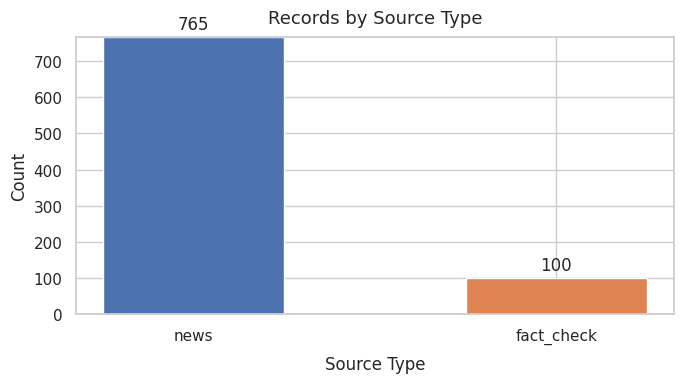

In [5]:
print('Shape:', df.shape)
print('\nSource type breakdown:')
print(df['source_type'].value_counts())
print('\nSentiment breakdown:')
print(df['sentiment'].value_counts())
print('\nMissing values:')
print(df[['text', 'verdict', 'claim']].isna().sum())

fig, ax = plt.subplots(figsize=(7, 4))
counts = df['source_type'].value_counts()
bars = ax.bar(counts.index, counts.values, width=0.5, color=['#4C72B0', '#DD8452', '#55A868'])
ax.bar_label(bars, padding=3)
ax.set_title('Records by Source Type', fontsize=13, pad=10)
ax.set_xlabel('Source Type', labelpad=8)
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() + 1)
plt.tight_layout()
plt.savefig(FIG_DIR / 'source_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Sentiment Analysis

TextBlob assigns a polarity score from -1 to +1 to each piece of text. I've bucketed these into three categories using ±0.05 thresholds:
- **positive** (> 0.05)
- **neutral** (−0.05 to 0.05)
- **negative** (< −0.05)


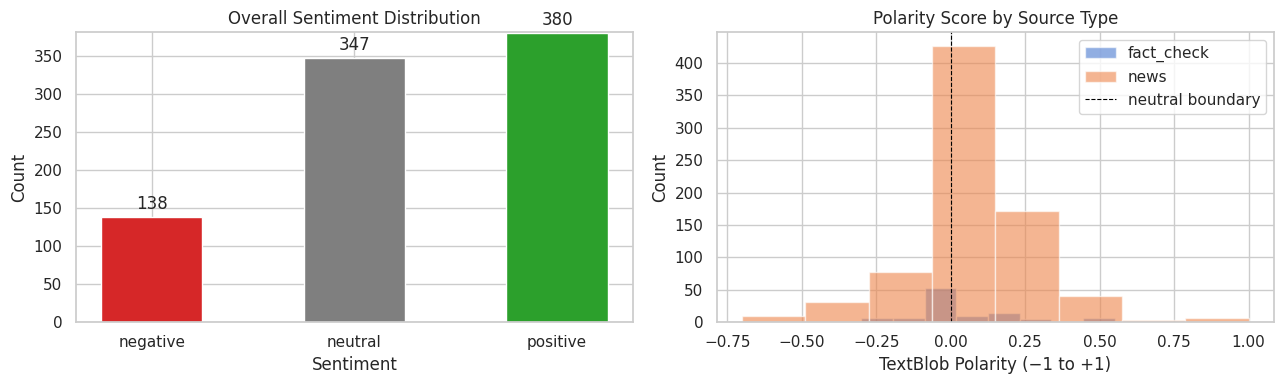

In [6]:
SENT_COLORS = {'negative': '#d62728', 'neutral': '#7f7f7f', 'positive': '#2ca02c'}
SENT_ORDER  = ['negative', 'neutral', 'positive']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sentiment count bar chart
counts = df['sentiment'].value_counts().reindex(SENT_ORDER, fill_value=0)
bars = axes[0].bar(counts.index, counts.values, width=0.5,
                   color=[SENT_COLORS[s] for s in counts.index])
axes[0].bar_label(bars, padding=3)
axes[0].set_title('Overall Sentiment Distribution', fontsize=12)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() + 1)

# Polarity score distribution by source type
for stype, group in df.groupby('source_type'):
    axes[1].hist(group['sentiment_score'], bins=8, alpha=0.6, label=stype)
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8, label='neutral boundary')
axes[1].set_title('Polarity Score by Source Type', fontsize=12)
axes[1].set_xlabel('TextBlob Polarity (−1 to +1)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'sentiment_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

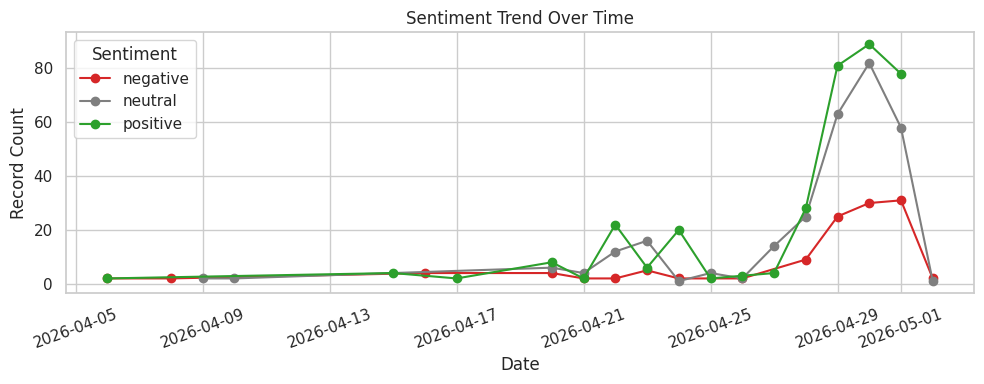

published_date sentiment  count
    2026-04-06  negative      2
    2026-04-06  positive      2
    2026-04-08  negative      2
    2026-04-09   neutral      2
    2026-04-10   neutral      2
    2026-04-15  positive      4
    2026-04-16  negative      4
    2026-04-17  positive      2
    2026-04-20   neutral      6
    2026-04-20  positive      8
    2026-04-20  negative      4
    2026-04-21  negative      2
    2026-04-21   neutral      4
    2026-04-21  positive      2
    2026-04-22  negative      2
    2026-04-22   neutral     12
    2026-04-22  positive     22
    2026-04-23  positive      6
    2026-04-23  negative      5
    2026-04-23   neutral     16
    2026-04-24  positive     20
    2026-04-24   neutral      1
    2026-04-24  negative      2
    2026-04-25   neutral      4
    2026-04-25  positive      2
    2026-04-26  negative      2
    2026-04-26   neutral      2
    2026-04-26  positive      3
    2026-04-27   neutral     14
    2026-04-27  positive      4
    2026

In [7]:
# Ensure datetime
df['published_date'] = pd.to_datetime(df['published_date'])

trend = (
    df.groupby(['published_date', 'sentiment'])
    .size()
    .reset_index(name='count')
    .sort_values('published_date')   # <-- sort here
)

fig, ax = plt.subplots(figsize=(10, 4))

for sentiment, group in trend.groupby('sentiment'):
    group = group.sort_values('published_date')  # <-- also sort each group
    ax.plot(group['published_date'], group['count'],
            marker='o', label=sentiment,
            color=SENT_COLORS.get(sentiment, 'grey'))

ax.set_title('Sentiment Trend Over Time', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Record Count')
ax.legend(title='Sentiment')

plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sentiment_over_time.png', dpi=120, bbox_inches='tight')
plt.show()

print(trend.to_string(index=False))

## 5. Media Bias Distribution

Source bias ratings come from a lookup table built on AllSides and Ad Fontes Media ratings. Five categories: **left**, **leans left**, **center**, **leans right**, **right**. Outlets not in the lookup (including fact-checking sites and X posts) are labelled **unknown**.

The right panel breaks down sentiment within each bias category — this is the core of the research question.


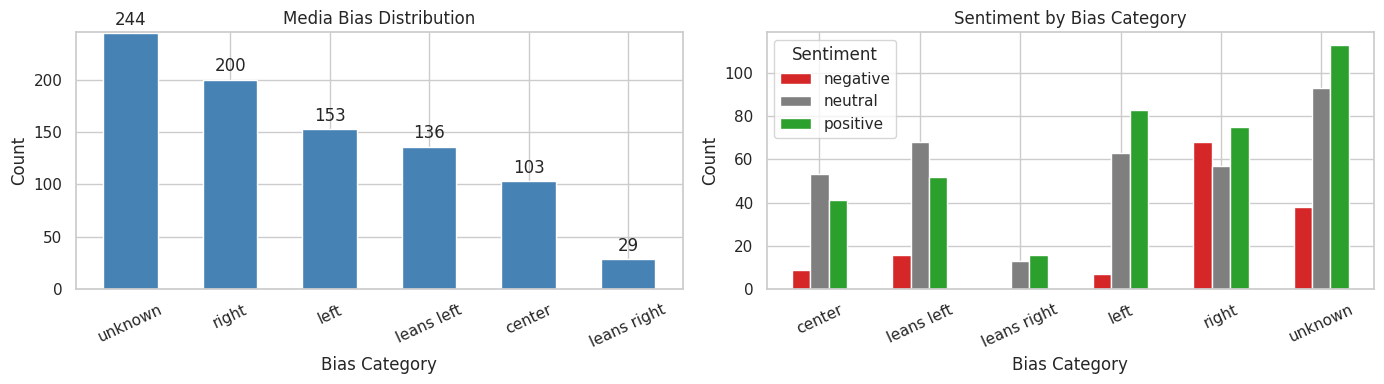

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bias distribution
bias_counts = df['media_bias'].value_counts()
bars = axes[0].bar(bias_counts.index, bias_counts.values, width=0.55, color='steelblue')
axes[0].bar_label(bars, padding=3)
axes[0].set_title('Media Bias Distribution', fontsize=12)
axes[0].set_xlabel('Bias Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_ylim(0, bias_counts.max() + 1)

# Sentiment breakdown within each bias group
bias_sent = (
    df.groupby(['media_bias', 'sentiment'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENT_ORDER, fill_value=0)
)
bias_sent.plot(kind='bar', ax=axes[1], width=0.55,
               color=[SENT_COLORS[s] for s in SENT_ORDER])
axes[1].set_title('Sentiment by Bias Category', fontsize=12)
axes[1].set_xlabel('Bias Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig(FIG_DIR / 'media_bias_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Fact-Check Verdicts

Fact-check records come from PolitiFact, FactCheck.org, and Snopes. I mapped their verdict labels into four buckets:

| Bucket | Includes |
|--------|----------|
| `false_or_mostly_false` | False, Mostly False, Pants on Fire, Four Pinocchios |
| `true_or_partly_true` | True, Mostly True, Half True |
| `mixture` | Mixture, Mixed |
| `unknown` | Unrated, blank, or unrecognized verdicts |


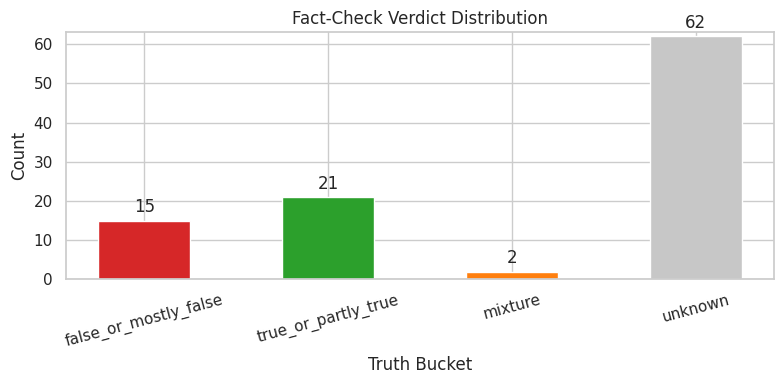


Fact-check evidence table:


,source_name,claim,verdict,truth_bucket
0,PolitiFact,Fentrice Driskell - What does federal law say about partisan gerrymandering? Fact-checking Florida Democratic leader,,unknown
1,PolitiFact,Bernie Sanders - Bernie Sanders said the GOP bill removed 15 million Americans from healthcare. That’s premature.,,unknown
2,PolitiFact,"Tim Scott - Despite a partial government shutdown, Secret Service personnel are receiving paychecks",,unknown
3,PolitiFact,Pine Tree Results PAC - Ad linked to Maine’s Susan Collins attacks Graham Platner’s 2013 rape comments. What are the...,,unknown
4,PolitiFact,Social Media - This isn’t ‘unedited raw security footage’ of the White House correspondents’ dinner shooter,,unknown
...,...,...,...,...
95,Snopes,Does video show major water pollution in India?,Miscaptioned,unknown
96,Snopes,Selfie shows suspected White House correspondents' dinner gunman shortly before shooting,True,true_or_partly_true
97,Snopes,No evidence Trump called Norah O'Donnell 'Nora O'Dumble' in social media post,Fake,unknown
98,Snopes,"Did Trump call Obama 'liberal dog,' order investigation into Catholic Church? Don't be fooled",Fake,unknown


In [9]:
fact_df = df[df['source_type'] == 'fact_check'].copy()

if fact_df.empty:
    print('No fact-check records in dataset.')
else:
    bucket_order  = ['false_or_mostly_false', 'true_or_partly_true', 'mixture', 'unproven', 'unknown']
    bucket_colors = {
        'false_or_mostly_false': '#d62728',
        'true_or_partly_true':   '#2ca02c',
        'mixture':               '#ff7f0e',
        'unproven':              '#9467bd',
        'unknown':               '#c7c7c7'
    }

    bucket_counts = fact_df['truth_bucket'].value_counts().reindex(bucket_order, fill_value=0)
    # only show non-zero buckets
    bucket_counts = bucket_counts[bucket_counts > 0]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(bucket_counts.index, bucket_counts.values, width=0.5,
                  color=[bucket_colors[b] for b in bucket_counts.index])
    ax.bar_label(bars, padding=3)
    ax.set_title('Fact-Check Verdict Distribution', fontsize=12)
    ax.set_xlabel('Truth Bucket')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(0, bucket_counts.max() + 1)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fact_check_verdicts.png', dpi=120, bbox_inches='tight')
    plt.show()

    print('\nFact-check evidence table:')
    display(fact_df[['source_name', 'claim', 'verdict', 'truth_bucket']].reset_index(drop=True))

# Conclusions

1) From the data, overall sentiment appears slightly positive or neutral, with positive (≈42.6%) and neutral (≈39.4%) coverage clearly outweighing negative (≈18.1%). 
2) Some link between bias and sentiment exists, but it’s not strong or consistent.
3) Unexpected result: left-leaning outlets appear slightly more positive than right-leaning ones.This is mainly due to TextBlob limitations (it reads tone of words, not true political intent)
   Right-leaning sources use more emotional language, which can be misclassified as negative.
4) Dataset is imbalanced and incomplete (missing Twitter data, fact-check verdicts not populated)
5) There is some indication like visible patterns that media bias affects sentiment but the relationship is not strong enough to make a definitive claim.
6) Biggest strength: a working pipeline that can be improved with better models and more data.
7) The dataset is relatively small and time-bound.
   
Limitations:
It highlights the limitation of data quality , dataset imbalance, data sources.

